<a href="https://colab.research.google.com/github/Nilamsari01/nilamsari046/blob/main/Copy_of_projectkecil_Nilam_Sari_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =================================================
# 1. DATA UNDERSTANDING & IMPORT LIBRARY
# =================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import RobustScaler
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import GradientBoostingRegressor
import warnings

In [ ]:
warnings.filterwarnings('ignore')

In [ ]:
# Load Dataset
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [ ]:
train.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

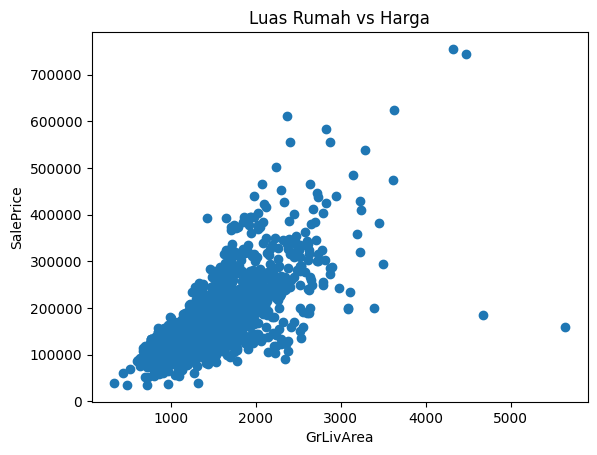

In [ ]:
#=======================================
# 2. Exploratory Data Analysis (EDA)
#=======================================
plt.figure()
plt.scatter(train['GrLivArea'], train['SalePrice'])
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.title('Luas Rumah vs Harga')
plt.show()

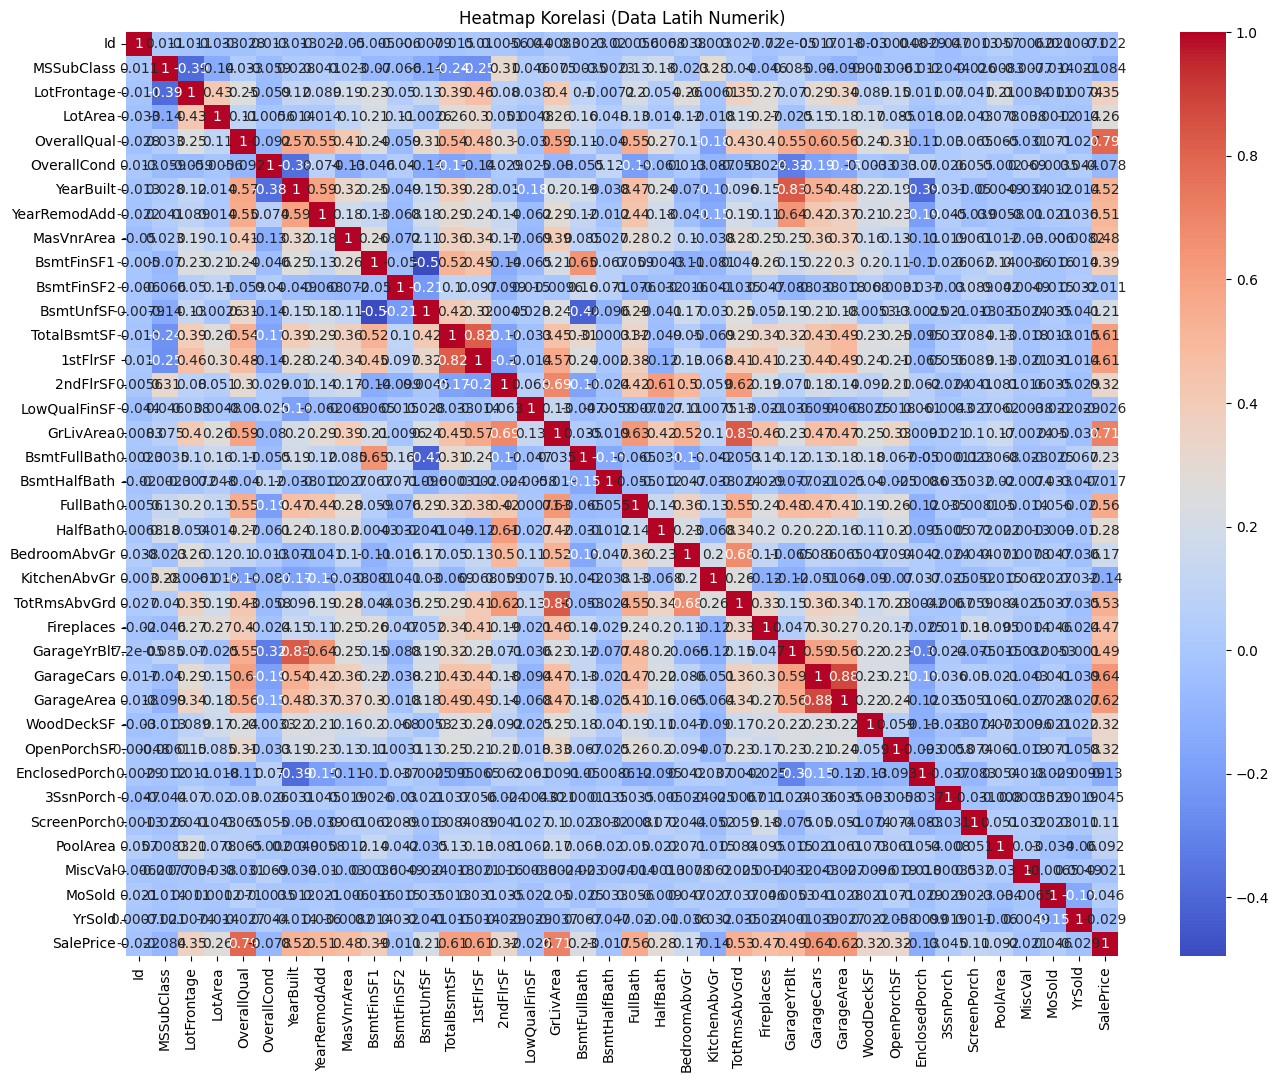

In [ ]:
plt.figure(figsize=(16,12))
sns.heatmap(train.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Heatmap Korelasi (Data Latih Numerik)")
plt.show()

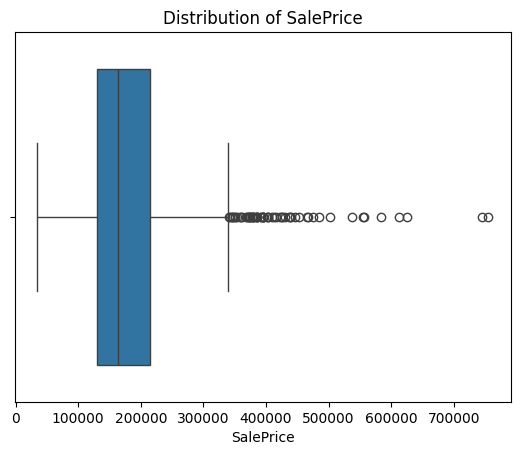

In [ ]:
sns.boxplot(x=train['SalePrice'])
plt.title('Distribution of SalePrice')
plt.show()

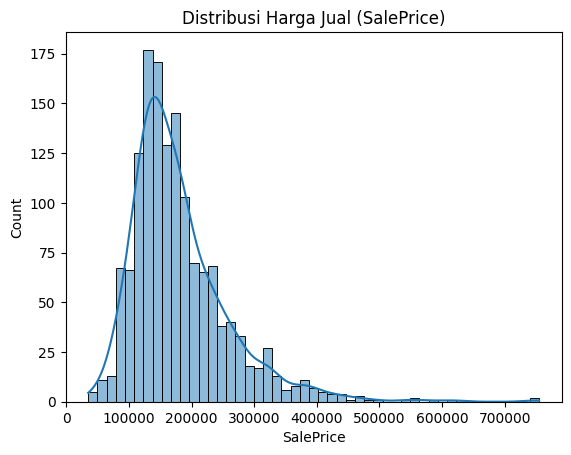

In [ ]:
sns.histplot(train['SalePrice'], kde=True)
plt.title("Distribusi Harga Jual (SalePrice)")
plt.show()

In [ ]:
# =================================================
# 3. DATA PREPROCESSING
# =================================================
# A. Menangani Outlier (Ditingkatkan)
# Menghapus anomali luas tanah vs harga
train = train.drop(train[(train['GrLivArea']>4000) & (train['SalePrice']<300000)].index)

# B. Transformasi Target ke Log Scale
y = np.log1p(train['SalePrice'])
X = train.drop(['SalePrice', 'Id'], axis=1)
test_id = test['Id']
X_test_final = test.drop('Id', axis=1)

# C. Feature Engineering
all_data = pd.concat([X, X_test_final])
all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']
all_data['TotalBath'] = all_data['FullBath'] + (0.5 * all_data['HalfBath']) + \
                        all_data['BsmtFullBath'] + (0.5 * all_data['BsmtHalfBath'])
all_data['PropertyAge'] = all_data['YrSold'] - all_data['YearBuilt']

# D. Handling Missing Values
for col in all_data.columns:
    if all_data[col].dtype == "object":
        all_data[col] = all_data[col].fillna(all_data[col].mode()[0])
    else:
        all_data[col] = all_data[col].fillna(all_data[col].median())

# E. Encoding (Disederhanakan untuk mengurangi fitur agar tidak overfit)
all_data = pd.get_dummies(all_data)

X_final = all_data[:len(y)]
X_submission = all_data[len(y):]

# F. Scaling
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_final)
X_submission_scaled = scaler.transform(X_submission)

In [ ]:
all_data.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,7,5,2003,2003,196.0,706.0,0.0,...,False,False,False,True,False,False,False,False,True,False
1,20,80.0,9600,6,8,1976,1976,0.0,978.0,0.0,...,False,False,False,True,False,False,False,False,True,False
2,60,68.0,11250,7,5,2001,2002,162.0,486.0,0.0,...,False,False,False,True,False,False,False,False,True,False
3,70,60.0,9550,7,5,1915,1970,0.0,216.0,0.0,...,False,False,False,True,True,False,False,False,False,False
4,60,84.0,14260,8,5,2000,2000,350.0,655.0,0.0,...,False,False,False,True,False,False,False,False,True,False


In [ ]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2917 entries, 0 to 1458
Columns: 289 entries, MSSubClass to SaleCondition_Partial
dtypes: bool(250), float64(13), int64(26)
memory usage: 1.6 MB


In [ ]:
all_data.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,TotalSF,TotalBath,PropertyAge
count,2917.000000,2917.000000,2917.000000,2917.000000,2917.000000,2917.000000,2917.000000,2917.000000,2917.000000,2917.000000,...,2917.000000,2917.000000,2917.000000,2917.000000,2917.000000,2917.000000,2917.000000,2917.000000,2917.000000,2917.000000
mean,57.135756,68.983888,10139.439150,6.086390,5.564964,1971.287967,1984.248200,100.931436,438.991087,49.599246,...,23.114158,2.604045,16.073363,2.088790,50.860816,6.213576,2007.792938,2543.053822,2.216661,36.504971
std,42.532140,20.810549,7807.036512,1.406704,1.113414,30.286991,20.892257,178.032499,444.108106,169.232130,...,64.263424,25.196714,56.202054,34.561371,567.595198,2.713070,1.315328,780.478256,0.806262,30.331531
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,334.000000,1.000000,-1.000000
25%,20.000000,60.000000,7476.000000,5.000000,5.000000,1953.000000,1965.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,2000.000000,1.500000,7.000000
50%,50.000000,68.000000,9452.000000,6.000000,5.000000,1973.000000,1993.000000,0.000000,368.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,2448.000000,2.000000,35.000000
75%,70.000000,78.000000,11556.000000,7.000000,6.000000,2001.000000,2004.000000,163.000000,733.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,2990.000000,2.500000,55.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,4010.000000,1526.000000,...,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,10190.000000,7.000000,136.000000


In [ ]:
# =================================================
# 4, 5, 6. EXPERIMENT: ANTI-OVERFITTING PARAMS
# =================================================
ratios = [0.3, 0.2, 0.1]
algos = {
    "XGBoost": {
        "model": XGBRegressor(random_state=42),
        "params": {
            'n_estimators': [1000, 2000],
            'learning_rate': [0.01, 0.05],
            'max_depth': [3],               # Tetap 3 agar tidak terlalu kompleks
            'subsample': [0.6],             # Menggunakan hanya 60% data per pohon
            'colsample_bytree': [0.4],      # Menggunakan hanya 40% fitur per pohon (Sangat Ampuh!)
            'reg_alpha': [0.5, 1.0],        # L1 Regularization (Anti-Overfit)
            'reg_lambda': [1.5, 2.0]        # L2 Regularization (Anti-Overfit)
        }
    },
    "LightGBM": {
        "model": LGBMRegressor(random_state=42, verbosity=-1),
        "params": {
            'n_estimators': [1000, 2000],
            'learning_rate': [0.01, 0.05],
            'num_leaves': [20, 31],
            'reg_alpha': [0.5],             # Regularisasi
            'reg_lambda': [1.5],            # Regularisasi
            'subsample': [0.6],
            'colsample_bytree': [0.4]
        }
    },
    "Gradient Boosting": {
        "model": GradientBoostingRegressor(random_state=42),
        "params": {
            'n_estimators': [1000],
            'learning_rate': [0.01, 0.05],
            'max_depth': [3],
            'min_samples_leaf': [5, 9],     # Memaksa daun memiliki lebih banyak data
            'max_features': ['sqrt']        # Membatasi jumlah fitur
        }
    }
}


In [ ]:
final_results = []
best_overall_model = None
best_r2 = 0

print("="*95)
print(f"{'Algoritma':<20} | {'Split':<10} | {'Train R2':<10} | {'Test R2':<10} | {'Gap':<8} | {'Status'}")
print("-"*95)

for ratio in ratios:
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=ratio, random_state=42)
    label = f"{int((1-ratio)*100)}:{int(ratio*100)}"

    for name, config in algos.items():
        gs = GridSearchCV(config["model"], config["params"], cv=3, scoring='r2', n_jobs=-1)
        gs.fit(X_train, y_train)

        best_m = gs.best_estimator_
        y_train_pred = best_m.predict(X_train)
        y_test_pred = best_m.predict(X_test)

        r2_train = r2_score(y_train, y_train_pred)
        r2_test = r2_score(y_test, y_test_pred)
        gap = r2_train - r2_test

        # Penentuan Status Berdasarkan Gap (Selisih)
        if gap > 0.03: # Jika selisih > 3%, dianggap mulai overfit
            status = "Overfitting"
        elif r2_test < 0.85:
            status = "Underfitting"
        else:
            status = "Good Fit"

        final_results.append([name, label, r2_train, r2_test, status])
        print(f"{name:<20} | {label:<10} | {r2_train:>8.2%} | {r2_test:>8.2%} | {gap:>7.2%} | {status}")

        # Simpan model terbaik mutlak
        if r2_test > best_r2:
            best_r2 = r2_test
            best_overall_model = best_m

Algoritma            | Split      | Train R2   | Test R2    | Gap      | Status
-----------------------------------------------------------------------------------------------
XGBoost              | 70:30      |   96.75% |   91.56% |   5.19% | Overfitting
LightGBM             | 70:30      |   98.66% |   90.38% |   8.28% | Overfitting
Gradient Boosting    | 70:30      |   95.12% |   90.29% |   4.83% | Overfitting
XGBoost              | 80:20      |   96.49% |   92.00% |   4.49% | Overfitting
LightGBM             | 80:20      |   98.49% |   90.53% |   7.96% | Overfitting
Gradient Boosting    | 80:20      |   97.80% |   90.76% |   7.04% | Overfitting
XGBoost              | 90:10      |   96.27% |   94.43% |   1.85% | Good Fit
LightGBM             | 90:10      |   98.37% |   92.53% |   5.84% | Overfitting
Gradient Boosting    | 90:10      |   97.92% |   95.15% |   2.77% | Good Fit


In [ ]:
# =================================================
# TAMBAHAN METRIK EVALUASI (MSE & MAE/MRE)
# =================================================

for ratio in ratios:
    # ... (bagian train_test_split tetap sama) ...

    for name, model in algos.items():
        # ... (bagian fit tetap sama) ...

        # Prediksi Test Set
        y_test_pred = best_m.predict(X_test)

        # Kembalikan ke harga asli untuk menghitung error yang riil
        y_test_real = np.expm1(y_test)
        y_pred_real = np.expm1(y_test_pred)

        # Hitung Metrik
        mse = mean_squared_error(y_test_real, y_pred_real)
        mae = mean_absolute_error(y_test_real, y_pred_real)
        # MRE (Mean Relative Error) dalam Persentase
        mre = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100

        print(f"[{name} - {label}]")
        print(f"   MSE : {mse:,.2f}")
        print(f"   MAE : ${mae:,.2f}")
        print(f"   MRE : {mre:.2f}%")
        print(f"   R2  : {r2_score(y_test, y_test_pred):.4f}")
        print("-" * 30)


[XGBoost - 90:10]
   MSE : 256,099,111.01
   MAE : $11,122.47
   MRE : 6.55%
   R2  : 0.9515
------------------------------
[LightGBM - 90:10]
   MSE : 256,099,111.01
   MAE : $11,122.47
   MRE : 6.55%
   R2  : 0.9515
------------------------------
[Gradient Boosting - 90:10]
   MSE : 256,099,111.01
   MAE : $11,122.47
   MRE : 6.55%
   R2  : 0.9515
------------------------------
[XGBoost - 90:10]
   MSE : 256,099,111.01
   MAE : $11,122.47
   MRE : 6.55%
   R2  : 0.9515
------------------------------
[LightGBM - 90:10]
   MSE : 256,099,111.01
   MAE : $11,122.47
   MRE : 6.55%
   R2  : 0.9515
------------------------------
[Gradient Boosting - 90:10]
   MSE : 256,099,111.01
   MAE : $11,122.47
   MRE : 6.55%
   R2  : 0.9515
------------------------------
[XGBoost - 90:10]
   MSE : 256,099,111.01
   MAE : $11,122.47
   MRE : 6.55%
   R2  : 0.9515
------------------------------
[LightGBM - 90:10]
   MSE : 256,099,111.01
   MAE : $11,122.47
   MRE : 6.55%
   R2  : 0.9515
----------------

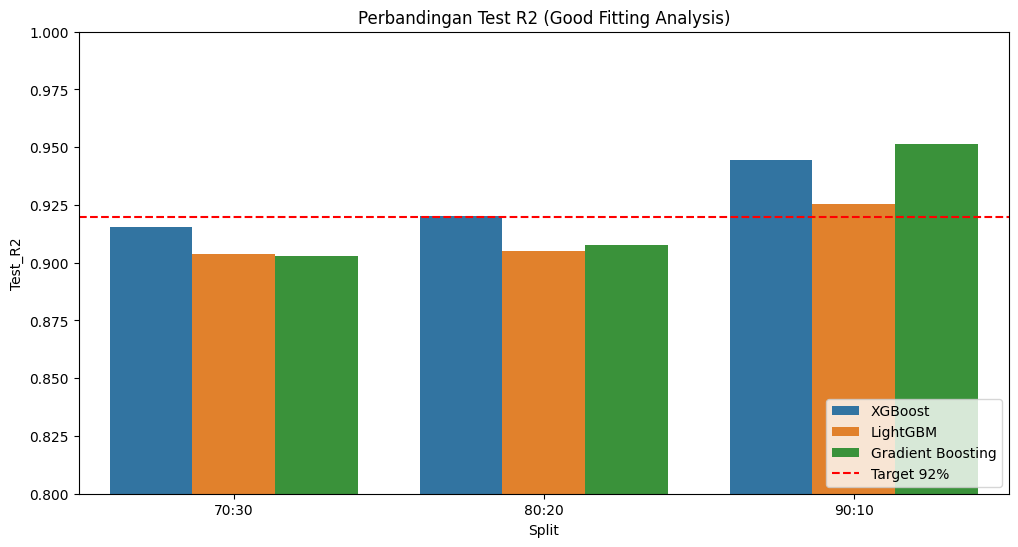

In [ ]:
# =================================================
# 7 & 8. EVALUATION & VISUALIZATION
# =================================================
comparison_df = pd.DataFrame(final_results, columns=['Algoritma', 'Split', 'Train_R2', 'Test_R2', 'Status'])

plt.figure(figsize=(12, 6))
sns.barplot(x='Split', y='Test_R2', hue='Algoritma', data=comparison_df)
plt.axhline(y=0.92, color='red', linestyle='--', label='Target 92%')
plt.title("Perbandingan Test R2 (Good Fitting Analysis)")
plt.ylim(0.80, 1.0)
plt.legend(loc='lower right')
plt.show()

In [ ]:
# =================================================
# 9. FINAL PREDICTION
# =================================================
print(f"\n>>> Menggunakan Model Terbaik untuk Prediksi Akhir: {best_overall_model} <<<")
final_preds = np.expm1(best_overall_model.predict(X_submission_scaled))

submission = pd.DataFrame({'Id': test_id, 'SalePrice': final_preds})
submission.to_csv('submission_good_fit.csv', index=False)
print("File 'submission_good_fit.csv' berhasil dibuat.")


# 1. Ambil satu rumah dari data test (sebagai contoh)
# Kita ambil rumah pertama (index 0)
rumah_baru = X_submission_scaled[0].reshape(1, -1)

# 2. Prediksi menggunakan model terbaik (best_overall_model)
hasil_log = best_overall_model.predict(rumah_baru)

# 3. Kembalikan ke harga asli (Inverse Log)
harga_asli = np.expm1(hasil_log)


>>> Menggunakan Model Terbaik untuk Prediksi Akhir: GradientBoostingRegressor(learning_rate=0.05, max_features='sqrt',
                          min_samples_leaf=5, n_estimators=1000,
                          random_state=42) <<<
File 'submission_good_fit.csv' berhasil dibuat.


Prediksi Harga Rumah: $122,907.70


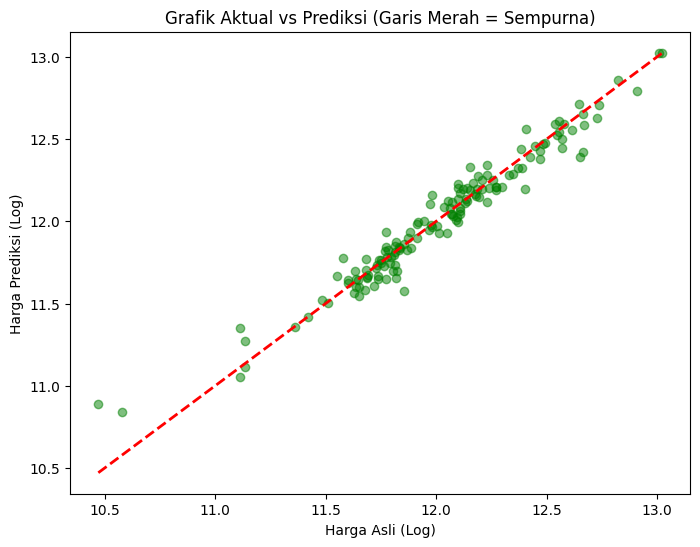

In [ ]:
print(f"Prediksi Harga Rumah: ${harga_asli[0]:,.2f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Harga Asli (Log)")
plt.ylabel("Harga Prediksi (Log)")
plt.title("Grafik Aktual vs Prediksi (Garis Merah = Sempurna)")
plt.show()